<a href="https://colab.research.google.com/github/jivaniaadit/factor_xa_cheminformatics/blob/main/notebooks/week2_day5_Random_Forest_QSAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install rdkit -q

In [ ]:
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors, rdFingerprintGenerator, AllChem, DataStructs
import pandas as pd
import numpy as np
from rdkit.Chem import MolStandardize
from rdkit.Chem.MolStandardize import rdMolStandardize
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pickle

df_clean = pd.read_csv('/content/drive/MyDrive/drugproj/factor_xa_clustered.csv')

with open('/content/drive/MyDrive/drugproj/splits.pkl', 'rb') as f:
    splits = pickle.load(f)

print(df_clean.shape, "| splits:", list(splits.keys()))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(3477, 16) | splits: ['random', 'scaffold', 'cluster']


In [ ]:
#Building RF function
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
mols = [Chem.MolFromSmiles(s) for s in df_clean['canonical_smiles_std']]

X = np.zeros((len(mols), 2048), dtype=np.int8)
for i, m in enumerate(mols):
    fp = mfpgen.GetFingerprint(m)
    DataStructs.ConvertToNumpyArray(fp, X[i])
y = df_clean['pKi'].values

def train_eval(split_name, splits, X, y):
    train_idx = splits[split_name]['train']
    test_idx = splits[split_name]['test']

    # index labels from pickle -> positional rows in X
    train_pos = df_clean.index.get_indexer(train_idx)
    test_pos = df_clean.index.get_indexer(test_idx)

    X_train, X_test = X[train_pos], X[test_pos]
    y_train, y_test = y[train_pos], y[test_pos]

    model = RandomForestRegressor(
        n_estimators=300,
        max_features='sqrt',
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)

    print(f"{split_name:10s} | R2 {r2:.3f} | MAE {mae:.3f} | RMSE {rmse:.3f} "
          f"| train {len(y_train)} test {len(y_test)}")
    return {'split': split_name, 'r2': r2, 'mae': mae, 'rmse': rmse,
            'model': model, 'y_test': y_test, 'preds': preds}

In [ ]:
#comparing the splits
results = {}
for split_name in ['random', 'scaffold', 'cluster']:
    if split_name in splits:
        results[split_name] = train_eval(split_name, splits, X, y)

random     | R2 0.784 | MAE 0.596 | RMSE 0.800 | train 2781 test 696
scaffold   | R2 0.694 | MAE 0.685 | RMSE 0.891 | train 2764 test 712
cluster    | R2 0.607 | MAE 0.786 | RMSE 1.026 | train 2775 test 702


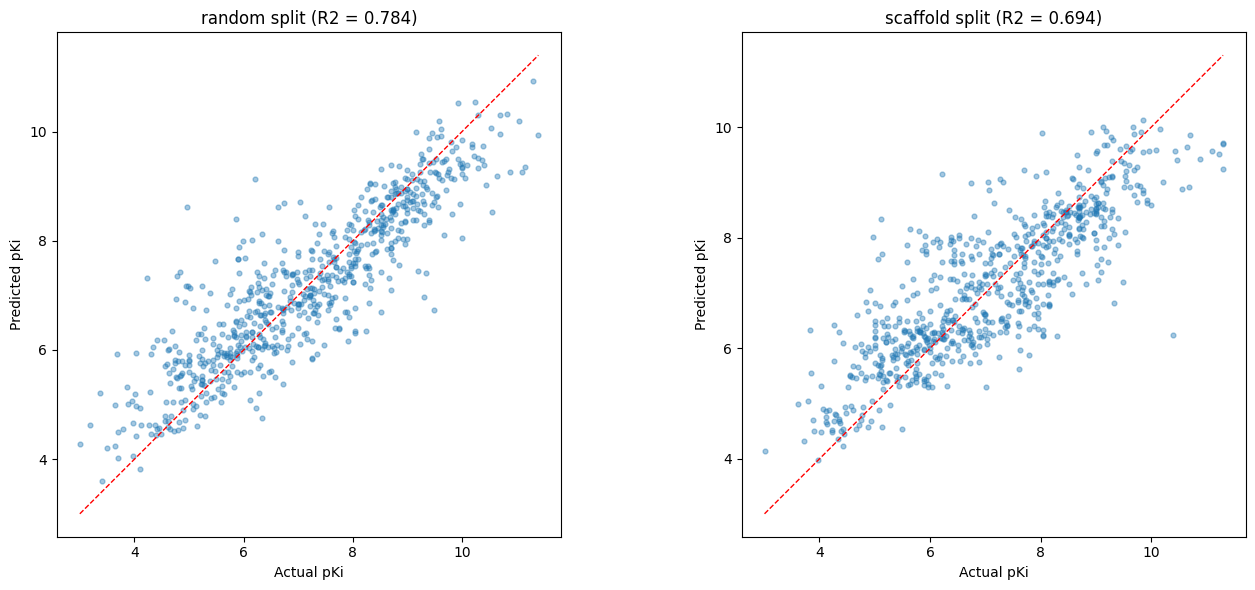

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, split_name in zip(axes, ['random', 'scaffold']):
    r = results[split_name]
    ax.scatter(r['y_test'], r['preds'], alpha=0.4, s=12)
    lims = [min(r['y_test'].min(), r['preds'].min()),
            max(r['y_test'].max(), r['preds'].max())]
    ax.plot(lims, lims, 'r--', lw=1)  # perfect prediction line
    ax.set_xlabel('Actual pKi')
    ax.set_ylabel('Predicted pKi')
    ax.set_title(f"{split_name} split (R2 = {r['r2']:.3f})")
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/drugproj/qsar_pred_vs_actual.png', dpi=150)
plt.show()

In [ ]:
# Feature Importance
model = results['scaffold']['model']
importances = model.feature_importances_
top_bits = np.argsort(importances)[::-1][:10]
print("Top 10 most important fingerprint bits:")
for rank, bit in enumerate(top_bits, 1):
    print(f"  {rank}. bit {bit}: importance {importances[bit]:.4f}")

Top 10 most important fingerprint bits:
  1. bit 233: importance 0.0148
  2. bit 1679: importance 0.0120
  3. bit 1754: importance 0.0118
  4. bit 1825: importance 0.0097
  5. bit 1683: importance 0.0088
  6. bit 1066: importance 0.0080
  7. bit 1956: importance 0.0079
  8. bit 140: importance 0.0078
  9. bit 1070: importance 0.0072
  10. bit 1852: importance 0.0068


In [ ]:
#Sanity Check
from sklearn.metrics import r2_score
for split_name in ['random', 'scaffold']:
    y_test = results[split_name]['y_test']
    baseline_pred = np.full_like(y_test, y[splits[split_name]['train'] and df_clean.index.get_indexer(splits[split_name]['train'])].mean() if False else y.mean())
    # simpler: baseline is mean of training y
    train_pos = df_clean.index.get_indexer(splits[split_name]['train'])
    baseline = np.full_like(y_test, y[train_pos].mean())
    print(f"{split_name}: baseline R2 = {r2_score(y_test, baseline):.3f} (should be ~0 or negative)")

random: baseline R2 = -0.001 (should be ~0 or negative)
scaffold: baseline R2 = -0.002 (should be ~0 or negative)


In [ ]:
summary = pd.DataFrame([
    {'split': r['split'], 'R2': r['r2'], 'MAE': r['mae'], 'RMSE': r['rmse']}
    for r in results.values()
])
summary.to_csv('/content/drive/MyDrive/drugproj/qsar_results.csv', index=False)
print(summary.to_string(index=False))

   split       R2      MAE     RMSE
  random 0.784144 0.596474 0.800062
scaffold 0.694155 0.685304 0.891239
 cluster 0.606755 0.786237 1.025771


Training a final model on all the data

In [ ]:
final_model = RandomForestRegressor(
    n_estimators=300,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)
final_model.fit(X, y)


Final model trained on all 3477 compounds


In [ ]:
def predict_pki(smiles, model, X_train, mfpgen, top_k=5):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {"error": f"could not parse SMILES: {smiles}"}

    # fingerprint the query, same settings as training
    fp = mfpgen.GetFingerprint(mol)
    query = np.zeros((1, 2048), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, query[0])

    # predict
    pred = model.predict(query)[0]

    # applicability domain: max Tanimoto to any training compound
    query_bits = fp
    train_fps = [DataStructs.cDataStructs.CreateFromBitString(
        ''.join(map(str, X_train[i]))) for i in range(0)]  # placeholder, see note
    # simpler similarity: use bulk Tanimoto on stored RDKit fps if you have them
    # fallback: compute against X_train numpy directly
    sims = []
    q = query[0].astype(bool)
    for row in X_train:
        r = row.astype(bool)
        inter = np.logical_and(q, r).sum()
        union = np.logical_or(q, r).sum()
        sims.append(inter / union if union > 0 else 0.0)
    sims = np.array(sims)
    max_sim = sims.max()
    mean_top_k = np.sort(sims)[::-1][:top_k].mean()

    # confidence flag
    if max_sim >= 0.6:
        confidence = "high (close to training data)"
    elif max_sim >= 0.4:
        confidence = "moderate"
    else:
        confidence = "low (out of domain, prediction unreliable)"

    return {
        "smiles": smiles,
        "predicted_pKi": round(float(pred), 2),
        "max_similarity_to_training": round(float(max_sim), 3),
        "mean_top5_similarity": round(float(mean_top_k), 3),
        "confidence": confidence,
    }

In [ ]:
# a known Factor Xa inhibitor from your data
test1 = df_clean['canonical_smiles_std'].iloc[0]
print(predict_pki(test1, final_model, X, mfpgen))

# a strcuture which looks like a factor Xa inhibitor
new_Xa = "O=C(Nc1ccccc1C(=O)Nc1ccccn1)c1cc(CNC(=O)c2ccc(Cl)s2)cs1"
print(predict_pki(new_Xa, final_model, X, mfpgen))

# caffeine, totally unrelated (should flag low confidence)
caffeine = "Cn1cnc2c1c(=O)n(C)c(=O)n2C"
print(predict_pki(caffeine, final_model, X, mfpgen))

{'smiles': 'CC(=N)N1CCC(Oc2ccc3nc(CCC(=O)O)n(Cc4ccc5ccc(C(=N)N)cc5c4)c3c2)CC1', 'predicted_pKi': 8.9, 'max_similarity_to_training': 1.0, 'mean_top5_similarity': 0.894, 'confidence': 'high (close to training data)'}
{'smiles': 'O=C(Nc1ccccc1C(=O)Nc1ccccn1)c1cc(CNC(=O)c2ccc(Cl)s2)cs1', 'predicted_pKi': 7.37, 'max_similarity_to_training': 0.427, 'mean_top5_similarity': 0.375, 'confidence': 'moderate'}
{'smiles': 'Cn1cnc2c1c(=O)n(C)c(=O)n2C', 'predicted_pKi': 6.56, 'max_similarity_to_training': 0.171, 'mean_top5_similarity': 0.169, 'confidence': 'low (out of domain, prediction unreliable)'}


In [ ]:
import joblib
joblib.dump(final_model, '/content/drive/MyDrive/drugproj/factor_xa_rf_final.joblib')
print("Model saved.")

Model saved.
